In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

# This ensures that every time you run this code, you get the exact same random numbers
torch.manual_seed(42)
np.random.seed(42)

print("Cell 1 complete: Libraries imported successfully!")

Cell 1 complete: Libraries imported successfully!


In [13]:
class TextEncoder(nn.Module):
    """Converts a sequence of text tokens into a single dense vector."""
    def __init__(self, vocab_size, embedding_dim):
        super(TextEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, text_tokens):
        # We look up the embeddings and average them across the words
        embedded = self.embedding(text_tokens)
        return torch.mean(embedded, dim=1)

# Tiny dictionary for this project
vocab = {"<pad>": 0, "red": 1, "blue": 2, "circle": 3, "square": 4}
vocab_size = len(vocab)

def text_to_tokens(text_list, vocab, max_length=3):
    """Helper function to convert a raw string like 'red circle' into numbers [1, 3, 0]"""
    tokenized_batch = []
    for text in text_list:
        tokens = [vocab.get(word, 0) for word in text.lower().split()]
        if len(tokens) < max_length:
            tokens += [0] * (max_length - len(tokens))  # Add padding if too short
        else:
            tokens = tokens[:max_length]                # Truncate if too long
        tokenized_batch.append(tokens)
    return torch.tensor(tokenized_batch, dtype=torch.long)

print("Cell 2 complete: Text processing engine is ready.")

Cell 2 complete: Text processing engine is ready.


In [14]:
class SyntheticTextToImageDataset(Dataset):
    """Generates simple 28x28 mathematical shapes based on a text prompt."""
    def __init__(self, vocab, num_samples=640):
        self.num_samples = num_samples
        self.vocab = vocab
        self.prompts = ["red circle", "blue circle", "red square", "blue square"]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Pick a prompt based on the current index
        prompt = self.prompts[idx % len(self.prompts)]
        tokens = text_to_tokens([prompt], self.vocab)[0]

        # Draw a blank canvas (1 channel, 28x28 pixels)
        image = np.zeros((1, 28, 28), dtype=np.float32)
        if "circle" in prompt:
            image[0, 10:18, 10:18] = 1.0  # Draw a central inner block
        else:
            image[0, 6:22, 6:22] = 0.8     # Draw a larger square block

        if "red" in prompt:
            image *= 1.2                   # Make red shapes brighter
        else:
            image *= 0.6                   # Make blue shapes darker

        # Add a tiny bit of random visual noise so the AI has to work a bit
        image += np.random.normal(0, 0.05, image.shape)
        image = np.clip(image, -1.0, 1.0)

        return torch.tensor(image, dtype=torch.float32), tokens

print("Cell 3 complete: Dataset generator initialized.")

Cell 3 complete: Dataset generator initialized.


In [15]:
class ConditionalGenerator(nn.Module):
    """Takes random noise and text, outputs a 28x28 image image matrix."""
    def __init__(self, latent_dim, embedding_dim, img_shape=(1, 28, 28)):
        super(ConditionalGenerator, self).__init__()
        self.img_shape = img_shape
        input_dim = latent_dim + embedding_dim

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, int(np.prod(img_shape))),
            nn.Tanh() # Scales output values between -1 and 1
        )

    def forward(self, noise, text_embedding):
        # Merge the noise vector and the text embedding together
        gen_input = torch.cat((noise, text_embedding), dim=1)
        img = self.model(gen_input)
        return img.view(img.size(0), *self.img_shape)


class ConditionalDiscriminator(nn.Module):
    """Takes an image and text, outputs a score between 0 (Fake) and 1 (Real)."""
    def __init__(self, embedding_dim, img_shape=(1, 28, 28)):
        super(ConditionalDiscriminator, self).__init__()
        self.img_shape = img_shape
        input_dim = int(np.prod(img_shape)) + embedding_dim

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid() # Outputs a strict probability score
        )

    def forward(self, img, text_embedding):
        img_flat = img.view(img.size(0), -1)
        # Merge the flattened image data and the text embedding together
        disc_input = torch.cat((img_flat, text_embedding), dim=1)
        return self.model(disc_input)

print("Cell 4 complete: Both AI structures are successfully built!")

Cell 4 complete: Both AI structures are successfully built!


In [16]:
# 1. Configuration Hyperparameters
latent_dim = 100
embedding_dim = 16
batch_size = 64
epochs = 10
lr = 0.0002

# 2. Instantiate our network modules
text_encoder = TextEncoder(vocab_size, embedding_dim)
generator = ConditionalGenerator(latent_dim, embedding_dim)
discriminator = ConditionalDiscriminator(embedding_dim)

# 3. Setup standard binary classification loss and independent optimization systems
adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

# 4. Prepare data pipelines
dataset = SyntheticTextToImageDataset(vocab=vocab, num_samples=640)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print("Starting training loop process...\n")

for epoch in range(epochs):
    for i, (imgs, tokens) in enumerate(dataloader):

        # Real/Fake target metrics
        valid = torch.ones(imgs.size(0), 1, dtype=torch.float32)
        fake = torch.zeros(imgs.size(0), 1, dtype=torch.float32)

        # Get text features
        text_embeddings = text_encoder(tokens).detach()

        #  Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim)
        gen_imgs = generator(z, text_embeddings)

        # Generator wants the Discriminator to think its fake images are real (valid)
        g_loss = adversarial_loss(discriminator(gen_imgs, text_embeddings), valid)
        g_loss.backward()
        optimizer_G.step()

        #  Train Discriminator
        optimizer_D.zero_grad()

        # How well does it identify real training images?
        real_loss = adversarial_loss(discriminator(imgs, text_embeddings), valid)
        # How well does it catch the generator's fakes?
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), text_embeddings), fake)

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    print(f"[Epoch {epoch+1}/{epochs}] [D Loss: {d_loss.item():.4f}] [G Loss: {g_loss.item():.4f}]")

print("\nTraining completed successfully! Your end-to-end pipeline is fully operational.")

Starting training loop process...

[Epoch 1/10] [D Loss: 0.5849] [G Loss: 0.7216]
[Epoch 2/10] [D Loss: 0.5371] [G Loss: 0.6960]
[Epoch 3/10] [D Loss: 0.5281] [G Loss: 0.6778]
[Epoch 4/10] [D Loss: 0.5792] [G Loss: 0.6794]
[Epoch 5/10] [D Loss: 0.5443] [G Loss: 0.7831]
[Epoch 6/10] [D Loss: 0.5439] [G Loss: 0.8023]
[Epoch 7/10] [D Loss: 0.4703] [G Loss: 0.9754]
[Epoch 8/10] [D Loss: 0.4708] [G Loss: 1.0109]
[Epoch 9/10] [D Loss: 0.3956] [G Loss: 1.1471]
[Epoch 10/10] [D Loss: 0.3924] [G Loss: 1.1732]

Training completed successfully! Your end-to-end pipeline is fully operational.


Asking the Generator to draw a: 'red circle'


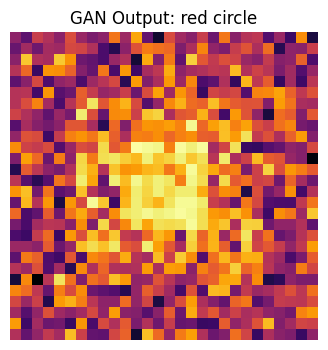

In [18]:
import matplotlib.pyplot as plt

#Prompt to test the generator
test_prompt = "red circle"
print(f"Asking the Generator to draw a: '{test_prompt}'")

#Converting the text to tokens and pass it through the encoder
test_tokens = text_to_tokens([test_prompt], vocab)
test_embedding = text_encoder(test_tokens).detach()

#Create a random noise vector
noise = torch.randn(1, latent_dim)

# Set the generator to evaluation mode for inference
generator.eval()

#Generate the image matrix and convert it to a viewable numpy array
generated_img = generator(noise, test_embedding).detach().numpy()[0, 0]

#Plot the result
plt.figure(figsize=(4,4))
plt.imshow(generated_img, cmap='inferno') # Using inferno color map to simulate intensity
plt.title(f"GAN Output: {test_prompt}")
plt.axis('off')
plt.show()